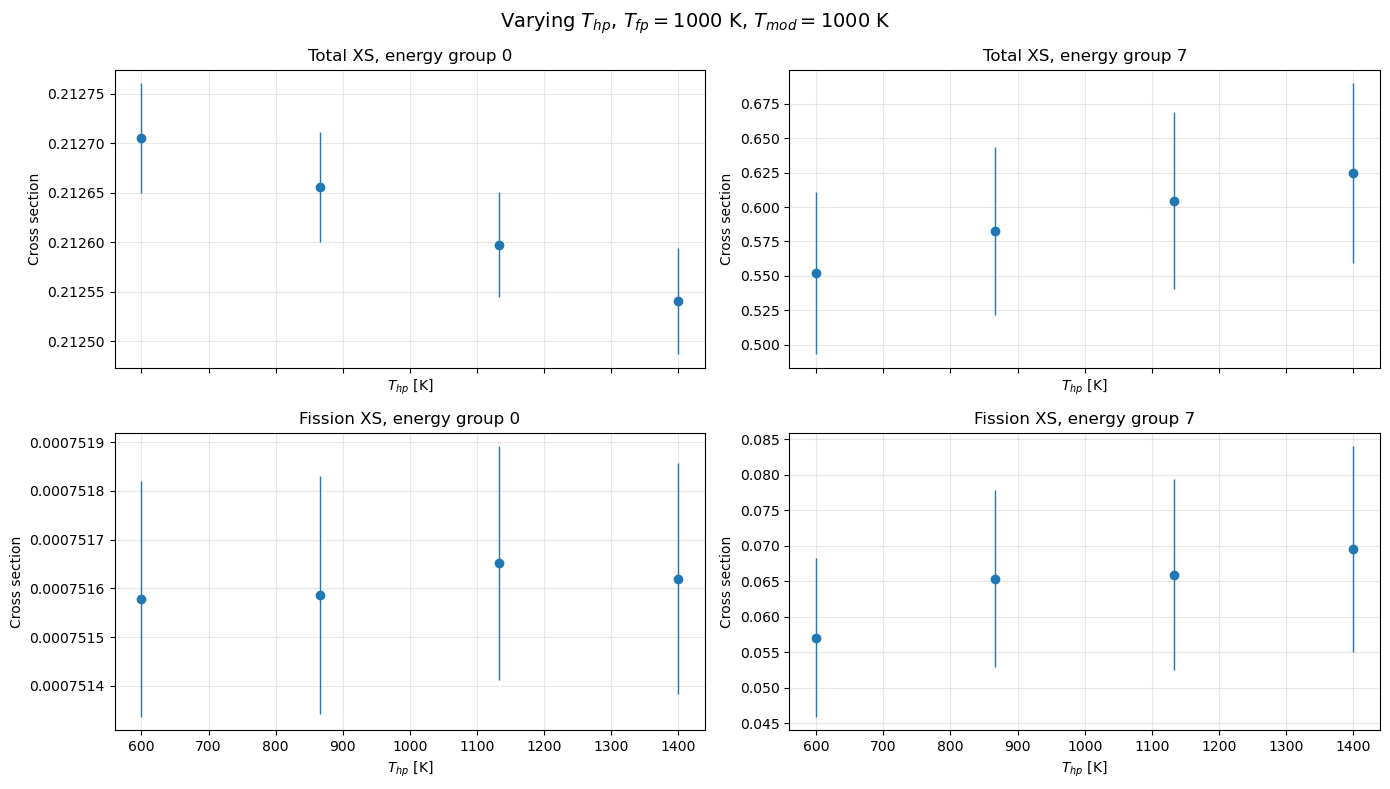

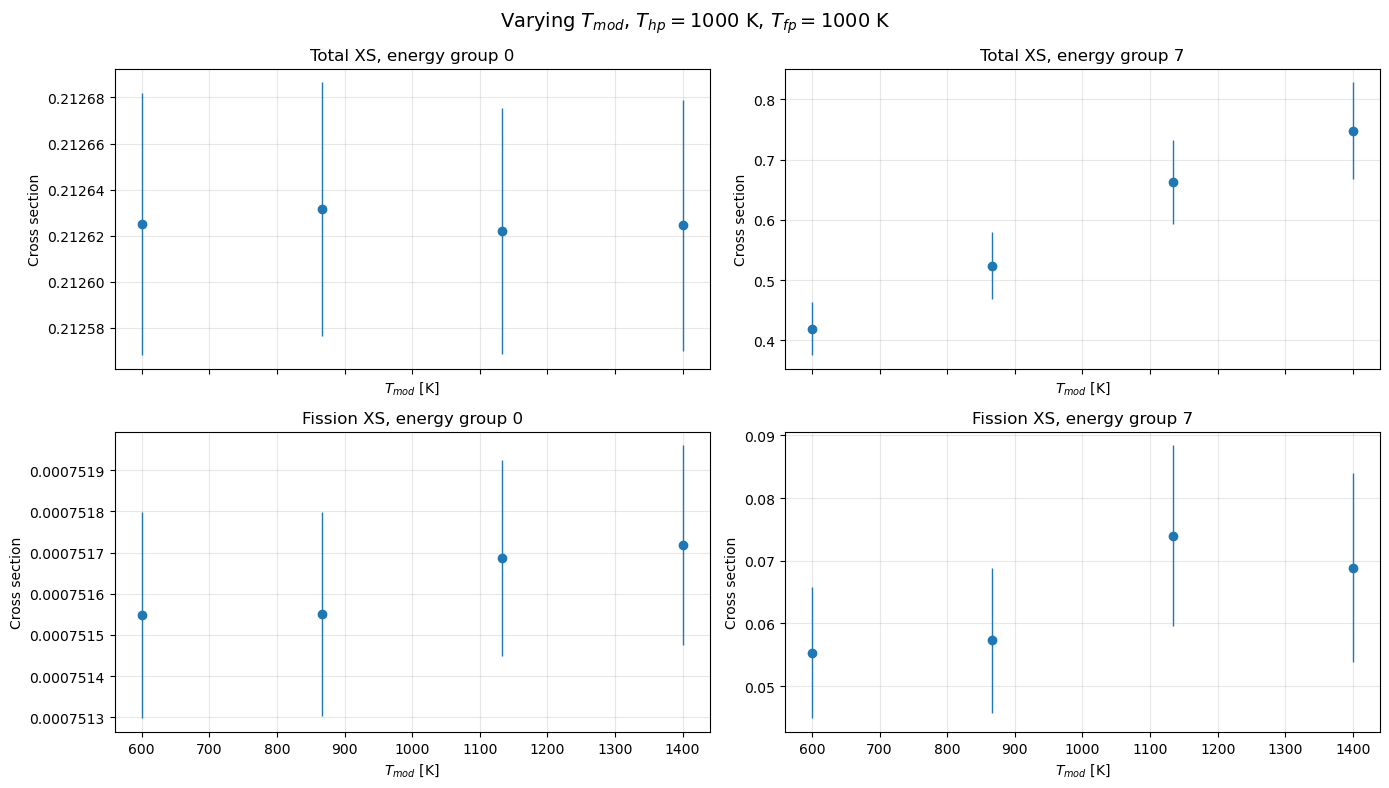

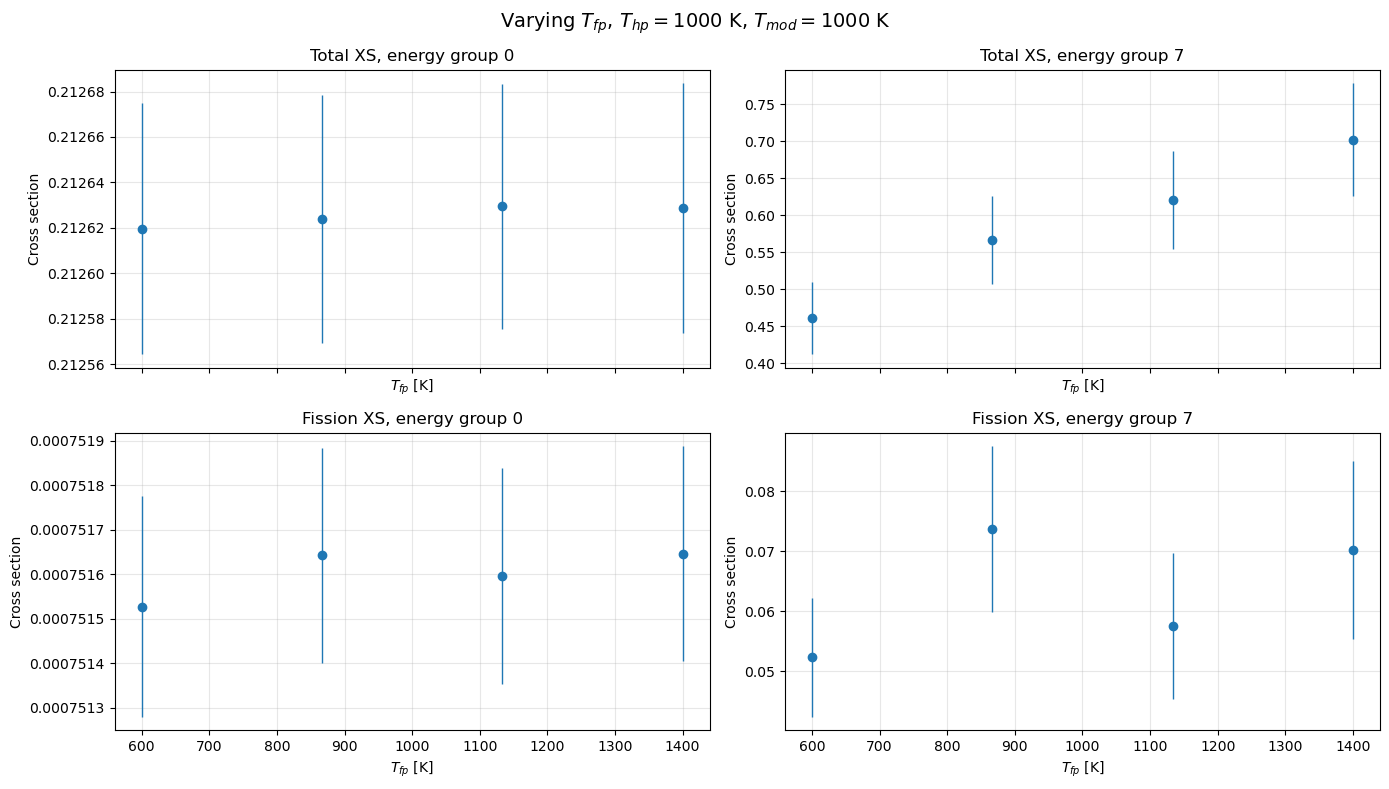

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from utils.interpolator import (
    TRAINING_DATA_FILE,
    METADATA_FILE,
    load_training_dataset,
    load_training_std_dataset,
)


def extract_target(Y, specs, key):
    """
    Extract one target from flattened Y using its TargetSpec.

    Returns
    -------
    arr : ndarray
        Shape is (n_samples, *target_shape)
    """
    spec = next(s for s in specs if s.name == key)

    arr_flat = Y[:, spec.start:spec.stop]
    arr = arr_flat.reshape((Y.shape[0],) + spec.shape)

    return arr


def build_regular_grid_interpolator(X, values):
    """
    Build a RegularGridInterpolator for values defined on X.

    Parameters
    ----------
    X : ndarray, shape (n_samples, 3)
        Columns are [T_hp, T_fp, T_mod].

    values : ndarray, shape (n_samples, ...)
        Values at each sample.

    Returns
    -------
    interpolator : RegularGridInterpolator
    axes : tuple
        Temperature axes: (t_hp, t_fp, t_mod)
    """
    t_hp = np.unique(X[:, 0])
    t_fp = np.unique(X[:, 1])
    t_mod = np.unique(X[:, 2])

    output_shape = values.shape[1:]

    grid_values = np.empty(
        (len(t_hp), len(t_fp), len(t_mod)) + output_shape,
        dtype=float,
    )

    index_map = {
        (float(row[0]), float(row[1]), float(row[2])): i
        for i, row in enumerate(X)
    }

    for i, hp in enumerate(t_hp):
        for j, fp in enumerate(t_fp):
            for k, mod in enumerate(t_mod):
                key = (float(hp), float(fp), float(mod))
                grid_values[i, j, k] = values[index_map[key]]

    interpolator = RegularGridInterpolator(
        points=(t_hp, t_fp, t_mod),
        values=grid_values,
        method="linear",
        bounds_error=True,
        fill_value=None,
    )

    return interpolator, (t_hp, t_fp, t_mod)


def plot_std_candles(ax, x, mean, std, title, xlabel):
    lower = mean - std
    upper = mean + std

    ax.vlines(x, lower, upper, linewidth=1.0)
    ax.plot(x, mean, linestyle="None", marker="o")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cross section")
    ax.grid(True, alpha=0.3)


def make_query_points(varying_axis, varying_values, fixed_temperature=1000.0):
    """
    Create query points where one temperature varies and the other two are fixed.

    Axis convention:
        0 = T_hp
        1 = T_fp
        2 = T_mod
    """
    X_query = np.full((len(varying_values), 3), fixed_temperature, dtype=float)
    X_query[:, varying_axis] = varying_values
    return X_query


def make_four_panel_plot(
    X_query,
    x_values,
    xlabel,
    figure_title,
    total_xs_interp,
    total_xs_std_interp,
    fission_xs_interp,
    fission_xs_std_interp,
):
    """
    Make one figure with four subplots:
        total XS group 0
        total XS group 7
        fission XS group 0
        fission XS group 7
    """
    total_xs = total_xs_interp(X_query)
    total_xs_std = total_xs_std_interp(X_query)

    fission_xs = fission_xs_interp(X_query)
    fission_xs_std = fission_xs_std_interp(X_query)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

    plot_std_candles(
        ax=axes[0, 0],
        x=x_values,
        mean=total_xs[:, 0],
        std=total_xs_std[:, 0],
        title="Total XS, energy group 0",
        xlabel=xlabel,
    )

    plot_std_candles(
        ax=axes[0, 1],
        x=x_values,
        mean=total_xs[:, 7],
        std=total_xs_std[:, 7],
        title="Total XS, energy group 7",
        xlabel=xlabel,
    )

    plot_std_candles(
        ax=axes[1, 0],
        x=x_values,
        mean=fission_xs[:, 0],
        std=fission_xs_std[:, 0],
        title="Fission XS, energy group 0",
        xlabel=xlabel,
    )

    plot_std_candles(
        ax=axes[1, 1],
        x=x_values,
        mean=fission_xs[:, 7],
        std=fission_xs_std[:, 7],
        title="Fission XS, energy group 7",
        xlabel=xlabel,
    )

    fig.suptitle(figure_title, fontsize=14)
    fig.tight_layout()

    return fig


def main():
    X, Y, specs, metadata = load_training_dataset(
        TRAINING_DATA_FILE,
        METADATA_FILE,
    )

    Y_std, std_specs = load_training_std_dataset(
        TRAINING_DATA_FILE,
        METADATA_FILE,
    )

    if Y_std is None or std_specs is None:
        raise RuntimeError("No Y_std/std_specs found in the saved dataset.")

    total_xs = extract_target(Y, specs, "total_xs")
    total_xs_std = extract_target(Y_std, std_specs, "total_xs_std")

    fission_xs = extract_target(Y, specs, "fission_xs")
    fission_xs_std = extract_target(Y_std, std_specs, "fission_xs_std")

    total_xs_interp, axes = build_regular_grid_interpolator(X, total_xs)
    total_xs_std_interp, _ = build_regular_grid_interpolator(X, total_xs_std)

    fission_xs_interp, _ = build_regular_grid_interpolator(X, fission_xs)
    fission_xs_std_interp, _ = build_regular_grid_interpolator(X, fission_xs_std)

    t_hp_axis, t_fp_axis, t_mod_axis = axes

    fixed_temperature = 1000.0

    # -------------------------------------------------------------------------
    # 1. Vary T_hp
    # -------------------------------------------------------------------------
    X_query_hp = make_query_points(
        varying_axis=0,
        varying_values=t_hp_axis,
        fixed_temperature=fixed_temperature,
    )

    make_four_panel_plot(
        X_query=X_query_hp,
        x_values=t_hp_axis,
        xlabel=r"$T_{hp}$ [K]",
        figure_title=(
            r"Varying $T_{hp}$, "
            r"$T_{fp} = 1000$ K, "
            r"$T_{mod} = 1000$ K"
        ),
        total_xs_interp=total_xs_interp,
        total_xs_std_interp=total_xs_std_interp,
        fission_xs_interp=fission_xs_interp,
        fission_xs_std_interp=fission_xs_std_interp,
    )

    # -------------------------------------------------------------------------
    # 2. Vary T_mod
    # -------------------------------------------------------------------------
    X_query_mod = make_query_points(
        varying_axis=2,
        varying_values=t_mod_axis,
        fixed_temperature=fixed_temperature,
    )

    make_four_panel_plot(
        X_query=X_query_mod,
        x_values=t_mod_axis,
        xlabel=r"$T_{mod}$ [K]",
        figure_title=(
            r"Varying $T_{mod}$, "
            r"$T_{hp} = 1000$ K, "
            r"$T_{fp} = 1000$ K"
        ),
        total_xs_interp=total_xs_interp,
        total_xs_std_interp=total_xs_std_interp,
        fission_xs_interp=fission_xs_interp,
        fission_xs_std_interp=fission_xs_std_interp,
    )

    # -------------------------------------------------------------------------
    # 3. Vary T_fp
    # -------------------------------------------------------------------------
    X_query_fp = make_query_points(
        varying_axis=1,
        varying_values=t_fp_axis,
        fixed_temperature=fixed_temperature,
    )

    make_four_panel_plot(
        X_query=X_query_fp,
        x_values=t_fp_axis,
        xlabel=r"$T_{fp}$ [K]",
        figure_title=(
            r"Varying $T_{fp}$, "
            r"$T_{hp} = 1000$ K, "
            r"$T_{mod} = 1000$ K"
        ),
        total_xs_interp=total_xs_interp,
        total_xs_std_interp=total_xs_std_interp,
        fission_xs_interp=fission_xs_interp,
        fission_xs_std_interp=fission_xs_std_interp,
    )

    plt.show()


if __name__ == "__main__":
    main()